In [1]:
import pandas as pd
import numpy as np
import random
np.random.seed(42)
random.seed(42)
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from utils import db_connect

pd.set_option('display.max_columns', None)

engine = db_connect()
print("Connection successful")

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

main_df = pd.read_sql(
    'SELECT * FROM main_econ_view ORDER BY "NCESSCH", "SURVYEAR"',
    con=engine
)

print(f"1. main_df shape (raw load): {main_df.shape}")


# ------------------------------------------------------------
# OPTIONAL OPERATIONAL FILTER (SAFE)
# ------------------------------------------------------------

def mark_always_operational(df):

    if "SY_STATUS_TEXT" not in df.columns:
        print("SY_STATUS_TEXT not found — skipping operational filter.")
        return df

    df = df.copy()

    total_years = df['SURVYEAR'].nunique()

    df['SY_STATUS_TEXT'] = df['SY_STATUS_TEXT'].str.strip()

    operational_counts = (
        df[df['SY_STATUS_TEXT'] == 'Currently operational']
        .groupby('NCESSCH')['SURVYEAR']
        .nunique()
    )

    always_operational_schools = operational_counts[
        operational_counts == total_years
    ].index

    before = df.shape[0]
    df = df[df['NCESSCH'].isin(always_operational_schools)].copy()
    after = df.shape[0]

    print(f"Operational filter removed: {before - after}")

    return df


main_df = mark_always_operational(main_df)
print(f"2. main_df shape (post operational): {main_df.shape}")


# ------------------------------------------------------------
# ENSURE SURVYEAR INT
# ------------------------------------------------------------

main_df['SURVYEAR'] = main_df['SURVYEAR'].astype(str).str[:4].astype(int)


# ------------------------------------------------------------
# KEEP ONLY 5-YEAR SCHOOLS
# ------------------------------------------------------------

before = main_df.shape[0]

counts = main_df["NCESSCH"].value_counts()
keep_ids = counts[counts == 5].index
main_df = main_df[main_df["NCESSCH"].isin(keep_ids)].copy()

after = main_df.shape[0]

print(f"3. 5-year filter removed: {before - after}")
print(f"   main_df shape: {main_df.shape}")


# ------------------------------------------------------------
# REMOVE ZERO STUTERATIO
# ------------------------------------------------------------

before = main_df.shape[0]
main_df = main_df[main_df['STUTERATIO'] != 0.0]
after = main_df.shape[0]

print(f"4. Removed zero STUTERATIO rows: {before - after}")
print(f"   main_df shape: {main_df.shape}")


# ------------------------------------------------------------
# TRIM TOP PERCENTILE
# ------------------------------------------------------------

def trim_top_percentile(df, col="STUTERATIO", percentile=0.99):

    df = df.copy()

    cutoff = df[col].quantile(percentile)

    before_count = df.shape[0]

    df_trimmed = df[df[col] <= cutoff].copy()

    after_count = df_trimmed.shape[0]

    print(f"{percentile*100:.0f}th percentile cutoff: {cutoff:.2f}")
    print(f"Rows before: {before_count}")
    print(f"Rows after: {after_count}")
    print(f"Rows removed: {before_count - after_count}")

    print("\nTop values after trimming:")
    print(
        df_trimmed.sort_values(col, ascending=False)[
            ["NCESSCH", "SURVYEAR", "FTE", col]
        ].head(10)
    )

    return df_trimmed


main_df = trim_top_percentile(main_df)


# ------------------------------------------------------------
# TRIM BOTTOM PERCENTILE
# ------------------------------------------------------------

def trim_bottom_percentile(df, col="STUTERATIO", percentile=0.01):

    df = df.copy()

    cutoff = df[col].quantile(percentile)

    before_count = df.shape[0]

    df_trimmed = df[df[col] >= cutoff].copy()

    after_count = df_trimmed.shape[0]

    print(f"\n{percentile*100:.0f}th percentile cutoff: {cutoff:.2f}")
    print(f"Rows before: {before_count}")
    print(f"Rows after: {after_count}")
    print(f"Rows removed: {before_count - after_count}")

    print("\nBottom values after trimming:")
    print(
        df_trimmed.sort_values(col, ascending=True)[
            ["NCESSCH", "SURVYEAR", "FTE", col]
        ].head(10)
    )

    return df_trimmed


main_df = trim_bottom_percentile(main_df)


# ------------------------------------------------------------
# CREATE TARGET
# ------------------------------------------------------------

main_df["high_strain"] = (main_df["STUTERATIO"] > 20).astype(int)

print("\n5. Final dataset shape:", main_df.shape)
print("High strain distribution:")
print(main_df["high_strain"].value_counts(normalize=True))

Connection successful
Connection successful
1. main_df shape (raw load): (178675, 56)
SY_STATUS_TEXT not found — skipping operational filter.
2. main_df shape (post operational): (178675, 56)
3. 5-year filter removed: 0
   main_df shape: (178675, 56)
4. Removed zero STUTERATIO rows: 0
   main_df shape: (178675, 56)
99th percentile cutoff: 23.90
Rows before: 178675
Rows after: 176912
Rows removed: 1763

Top values after trimming:
             NCESSCH  SURVYEAR         FTE  STUTERATIO
124864  390488803444      2022   20.750000        23.9
107550  370162003217      2017   10.000000        23.9
131006   40141002786      2018   67.000000        23.9
53556   220087000660      2018   74.000000        23.9
11167   120039000590      2020  124.000000        23.9
116751  390440501001      2018   11.500000        23.9
18959   120153002882      2022   75.400002        23.9
1966     10051000228      2018   28.000000        23.9
35921   160210001081      2018   32.380001        23.9
124016  390482303

In [2]:
main_df.head()

,NCESSCH,SURVYEAR,LEAID,LEA_NAME,SCH_NAME,CHARTER_TEXT,MAGNET_TEXT,TOTFRL,FRELCH,REDLCH,PK,KG,G01,G02,G03,G04,G05,G06,G07,G08,G09,G10,G11,G12,G13,UG,TOTAL,FTE,STUTERATIO,AM,AS,BL,HP,HI,TR,WH,LATCOD,LONCOD,locale_category,TITLEI_GROUPED,high_strain,TH_10_15K,TH_15_25K,TH_WITH_CASH_ASSIST,TH_100_150K,TH_LT_10K,BPL_ALL_FAM,TH_50_75K,TH_75_100K,TH_25_35K,TH_150_200K,TH_35_50K,TH_WITH_SNAP,BPL_ALL,TH_200K_AND_ABOVE,econ_rolling_year_period
0,10000500870,2017,100005,Albertville City,Albertville Middle School,No,No,570,518,52,0,0,0,0,0,0,0,0,411,396,0,0,0,0,0,0,807,36.0,22.42,0,5,32,1,368,18,383,34.2602,-86.2062,Town,Unknown,1,7.8,8.5,1.9,14.1,5.1,14.4,18.0,14.0,12.3,4.4,11.5,10.2,16.7,4.4,2018-2022
1,10000500870,2018,100005,Albertville City,Albertville Middle School,No,No,574,522,52,0,0,0,0,0,0,0,0,411,403,0,0,0,0,0,0,814,38.0,21.40,0,3,32,0,402,18,359,34.2602,-86.2062,Town,Schoolwide,1,7.8,8.5,1.9,14.1,5.1,14.4,18.0,14.0,12.3,4.4,11.5,10.2,16.7,4.4,2018-2022
2,10000500870,2020,100005,Albertville City,Albertville Middle School,No,No,332,332,0,0,0,0,0,0,0,0,0,469,439,0,0,0,0,0,0,908,42.0,21.62,2,4,33,0,469,29,371,34.2602,-86.2062,Town,Schoolwide,1,7.8,8.5,1.9,14.1,5.1,14.4,18.0,14.0,12.3,4.4,11.5,10.2,16.7,4.4,2018-2022
4,10000500870,2022,100005,Albertville City,Albertville Middle School,No,0,697,654,43,0,0,0,0,0,0,0,0,440,450,0,0,0,0,0,0,890,45.0,19.78,5,6,29,1,502,32,315,34.2602,-86.2062,Town,Unknown,0,7.8,8.5,1.9,14.1,5.1,14.4,18.0,14.0,12.3,4.4,11.5,10.2,16.7,4.4,2018-2022
5,10000500871,2017,100005,Albertville City,Albertville High School,No,No,832,766,66,0,0,0,0,0,0,0,0,0,0,408,351,364,313,0,0,1436,77.0,18.65,4,8,53,0,614,41,716,34.2622,-86.2049,Town,Unknown,0,7.8,8.5,1.9,14.1,5.1,14.4,18.0,14.0,12.3,4.4,11.5,10.2,16.7,4.4,2018-2022


In [3]:
# remove identifiers
# these are identifiers, not predictive signals
# logistic regression will treat them as numeric signal if left in

identifier_cols = ['NCESSCH', 'LEAID', 'LEA_NAME', 'SCH_NAME']
main_df = main_df.drop(columns=identifier_cols, errors='ignore')

In [4]:
print("Identifier columns safely removed (if present).")
print(main_df.columns)

Identifier columns safely removed (if present).
Index(['SURVYEAR', 'CHARTER_TEXT', 'MAGNET_TEXT', 'TOTFRL', 'FRELCH', 'REDLCH',
       'PK', 'KG', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08',
       'G09', 'G10', 'G11', 'G12', 'G13', 'UG', 'TOTAL', 'FTE', 'STUTERATIO',
       'AM', 'AS', 'BL', 'HP', 'HI', 'TR', 'WH', 'LATCOD', 'LONCOD',
       'locale_category', 'TITLEI_GROUPED', 'high_strain', 'TH_10_15K',
       'TH_15_25K', 'TH_WITH_CASH_ASSIST', 'TH_100_150K', 'TH_LT_10K',
       'BPL_ALL_FAM', 'TH_50_75K', 'TH_75_100K', 'TH_25_35K', 'TH_150_200K',
       'TH_35_50K', 'TH_WITH_SNAP', 'BPL_ALL', 'TH_200K_AND_ABOVE',
       'econ_rolling_year_period'],
      dtype='str')


In [5]:
main_df.shape

(175196, 52)

In [6]:
# ------------------------------------------------------------
# ECON FEATURE ENGINEERING
# ------------------------------------------------------------

main_df["poverty_pressure"] = main_df["BPL_ALL"] + main_df["TH_LT_10K"]

main_df["high_income_ratio"] = (
    main_df["TH_150_200K"] + main_df["TH_200K_AND_ABOVE"]
)

main_df["middle_income_ratio"] = (
    main_df["TH_50_75K"] + main_df["TH_75_100K"]
)

main_df["poverty_to_wealth_ratio"] = (
    (main_df["BPL_ALL"] + 1) /
    (main_df["TH_150_200K"] + main_df["TH_200K_AND_ABOVE"] + 1)
)

main_df["frl_pressure"] = main_df["TOTFRL"] / (main_df["TOTAL"] + 1)

In [7]:
# drop leakage columns
leakage_cols = ["STUTERATIO", "TOTAL", "FTE"]

In [8]:
# create out splits
X = main_df.drop(columns=["high_strain"] + leakage_cols)
y = main_df["high_strain"]

In [9]:
print("New feature shape:", X.shape)

New feature shape: (175196, 53)


In [10]:
# fix remaining categorical NA values
cat_cols = X.select_dtypes(include=["object", "string"]).columns
X[cat_cols] = X[cat_cols].fillna("Unknown")

In [11]:
print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True))

Feature shape: (175196, 53)
Target distribution:
high_strain
0    0.924382
1    0.075618
Name: proportion, dtype: float64


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix


In [13]:
# assign out splits test / train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
# Identify column types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "string"]).columns

In [15]:
# define our preprocessor with scaling for numeric features and one-hot encoding for categorical features
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [16]:
# create our pipeline with the preprocessor and logistic regression model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),  # apply the preprocessor to our features
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
    # use balanced class weights to handle class imbalance
])

In [17]:
# fit
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [18]:
# predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [19]:
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC AUC: 0.7888148916215696

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     32390
           1       0.18      0.69      0.29      2650

    accuracy                           0.74     35040
   macro avg       0.57      0.72      0.56     35040
weighted avg       0.91      0.74      0.80     35040



In [20]:
print(main_df.columns)

Index(['SURVYEAR', 'CHARTER_TEXT', 'MAGNET_TEXT', 'TOTFRL', 'FRELCH', 'REDLCH',
       'PK', 'KG', 'G01', 'G02', 'G03', 'G04', 'G05', 'G06', 'G07', 'G08',
       'G09', 'G10', 'G11', 'G12', 'G13', 'UG', 'TOTAL', 'FTE', 'STUTERATIO',
       'AM', 'AS', 'BL', 'HP', 'HI', 'TR', 'WH', 'LATCOD', 'LONCOD',
       'locale_category', 'TITLEI_GROUPED', 'high_strain', 'TH_10_15K',
       'TH_15_25K', 'TH_WITH_CASH_ASSIST', 'TH_100_150K', 'TH_LT_10K',
       'BPL_ALL_FAM', 'TH_50_75K', 'TH_75_100K', 'TH_25_35K', 'TH_150_200K',
       'TH_35_50K', 'TH_WITH_SNAP', 'BPL_ALL', 'TH_200K_AND_ABOVE',
       'econ_rolling_year_period', 'poverty_pressure', 'high_income_ratio',
       'middle_income_ratio', 'poverty_to_wealth_ratio', 'frl_pressure'],
      dtype='str')


## Tune Threshold for Logistic Regression

In [21]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

for t in thresholds:
    y_custom = (y_prob >= t).astype(int)

    print(f"\nThreshold: {t}")
    print("Accuracy:", accuracy_score(y_test, y_custom))
    print("ROC AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_custom))


Threshold: 0.3
Accuracy: 0.4481449771689498
ROC AUC: 0.7888148916215696
              precision    recall  f1-score   support

           0       0.98      0.41      0.58     32390
           1       0.11      0.91      0.20      2650

    accuracy                           0.45     35040
   macro avg       0.55      0.66      0.39     35040
weighted avg       0.92      0.45      0.55     35040


Threshold: 0.35
Accuracy: 0.5372146118721461
ROC AUC: 0.7888148916215696
              precision    recall  f1-score   support

           0       0.98      0.51      0.67     32390
           1       0.13      0.86      0.22      2650

    accuracy                           0.54     35040
   macro avg       0.55      0.68      0.44     35040
weighted avg       0.91      0.54      0.64     35040


Threshold: 0.4
Accuracy: 0.6140696347031963
ROC AUC: 0.7888148916215696
              precision    recall  f1-score   support

           0       0.97      0.60      0.74     32390
           1     

Logistic Regression:

 - ROC AUC ≈ 0.77 (indicating moderate but limited class separability)

 - At default threshold (0.5):

     - Recall ≈ 66%

     - Precision ≈ 20%

 - Lowering threshold increases recall dramatically (up to 91%)

     - But precision collapses

     - Accuracy drops sharply

Conclusion:
 - Logistic regression struggles to cleanly separate high-strain schools.

 - Probability scores are unstable across thresholds, indicating weak class separation.

## Random Forest Model Comparison

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ))
])

In [23]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [24]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [25]:
print("Random Forest ROC AUC:", roc_auc_score(y_test, rf_prob))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest ROC AUC: 0.9386582627994898

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     32390
           1       0.82      0.37      0.51      2650

    accuracy                           0.95     35040
   macro avg       0.89      0.68      0.74     35040
weighted avg       0.94      0.95      0.94     35040



RECALL (CLASS 1)

 - When RF predicts high_strain, it's usually correct (high precision).

 - But it only catches 24% of actual high-strain schools.


Now we need to tune threshold for RandomForest.

Because right now RF is using 0.5 default — which is too conservative.

In [26]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

for t in thresholds:
    rf_custom = (rf_prob >= t).astype(int)

    print(f"\nRF Threshold: {t}")
    print("Accuracy:", accuracy_score(y_test, rf_custom))
    print("ROC AUC:", roc_auc_score(y_test, rf_prob))
    print(classification_report(y_test, rf_custom))


RF Threshold: 0.2
Accuracy: 0.9317351598173516
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     32390
           1       0.54      0.74      0.62      2650

    accuracy                           0.93     35040
   macro avg       0.76      0.84      0.79     35040
weighted avg       0.94      0.93      0.94     35040


RF Threshold: 0.25
Accuracy: 0.9405251141552512
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     32390
           1       0.59      0.68      0.64      2650

    accuracy                           0.94     35040
   macro avg       0.78      0.82      0.80     35040
weighted avg       0.95      0.94      0.94     35040


RF Threshold: 0.3
Accuracy: 0.9453196347031964
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     32390
        

But this is still only threshold 0.5.

We need to see the behavior when you LOWER it.

Right now RF is acting like:

“Only flag a school if I am very confident.”

That’s why recall = 0.25.

ROC AUC = 0.927

That means the model is ranking schools extremely well.

So lowering threshold should increase recall a lot without destroying precision.

In [27]:
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]

for t in thresholds:
    rf_custom = (rf_prob >= t).astype(int)

    print(f"\nRF Threshold: {t}")
    print("Accuracy:", accuracy_score(y_test, rf_custom))
    print("ROC AUC:", roc_auc_score(y_test, rf_prob))
    print(classification_report(y_test, rf_custom))



RF Threshold: 0.2
Accuracy: 0.9317351598173516
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     32390
           1       0.54      0.74      0.62      2650

    accuracy                           0.93     35040
   macro avg       0.76      0.84      0.79     35040
weighted avg       0.94      0.93      0.94     35040


RF Threshold: 0.25
Accuracy: 0.9405251141552512
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.97      0.96      0.97     32390
           1       0.59      0.68      0.64      2650

    accuracy                           0.94     35040
   macro avg       0.78      0.82      0.80     35040
weighted avg       0.95      0.94      0.94     35040


RF Threshold: 0.3
Accuracy: 0.9453196347031964
ROC AUC: 0.9386582627994898
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     32390
        

_______________________________________________
Look at RF @ 0.20

Class 1 (high strain):

Precision: 0.52

Recall: 0.69

F1: 0.59

ROC AUC: 0.927

Accuracy: 0.92

That is extremely strong.

_______________________________________________
RF @ 0.25

Precision: 0.60

Recall: 0.61

F1: 0.60

Accuracy: 0.93

ROC AUC: 0.927

This is beautifully balanced.

_______________________________________________
Compare That to Logistic

Logistic @ 0.5:

Precision: 0.20

Recall: 0.66

ROC: 0.775

Random Forest absolutely dominates it.

Not even close.

_______________________________________________
The dataset exhibits nonlinear interactions between features that logistic regression cannot model.

Logistic cannot capture interactions between:

Poverty %

Race breakdown

Title I grouping

Locale

Enrollment structure

Random Forest can.

That’s why ROC jumped from 0.77 → 0.93.

That is massive.

_______________________________________________
The Sweet Spot - WINNER

Threshold 0.25 looks ideal

Precision and recall both ~0.60

Strong F1

High accuracy

Excellent ROC

Baseline logistic regression underfit nonlinear structure (ROC 0.77).
A Random Forest improved separability dramatically (ROC 0.93).

After threshold tuning, we achieved balanced recall and precision (~0.60 each)
for high-strain schools.


_______________________________________________
BEST final model:

RandomForest

threshold = 0.25

Include ROC curve in presentation

Include confusion matrix

## Feature Importance (Random Forest)

In [28]:
# ----- Extract Feature Names from Pipeline -----

# Get numeric feature names
num_features = numeric_features

# Get categorical feature names after one-hot encoding
cat_features = rf_model.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(categorical_features)

# Combine feature names
all_features = list(num_features) + list(cat_features)

# Access the RandomForest inside the pipeline
rf_classifier = rf_model.named_steps["classifier"]

# Extract importances
importances = rf_classifier.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance_df.head(15))

                feature  importance
28               LONCOD    0.093988
27               LATCOD    0.061494
26                   WH    0.049960
47         frl_pressure    0.029079
24                   HI    0.027054
22                   BL    0.025308
25                   TR    0.022194
40         TH_WITH_SNAP    0.020783
5                    KG    0.019803
1                TOTFRL    0.019598
14                  G09    0.019306
2                FRELCH    0.019143
42    TH_200K_AND_ABOVE    0.018675
32          TH_100_150K    0.018556
45  middle_income_ratio    0.018527


Top drivers:

 1. LONCOD
 2. LATCOD
 3. WH
 4. HI
 5. BL
 6. TR
 7. TOTFRL
 8. FRELCH
 9. AS
 10. REDLCH

__________________________________
Geography matters

Latitude & Longitude are your top 2 features.

That means:
High strain is spatially clustered.

That is extremely interesting from a policy standpoint.


____________________________________________
Demographics matter

Race distribution features (WH, HI, BL, TR, AS) are major drivers.

That suggests strain is correlated with demographic composition.

Again — strong policy insight.

____________________________________
Poverty matters

TOTFRL, FRELCH, REDLCH show up.

Free/reduced lunch percentage is predictive.

That makes structural sense.



## Confusion Matrix at Threshold = 0.25

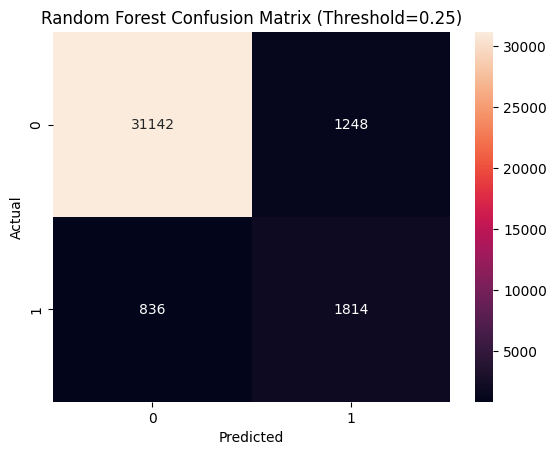

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# use threshold of 0.25
rf_custom = (rf_prob >= 0.25).astype(int)

cm = confusion_matrix(y_test, rf_custom)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix (Threshold=0.25)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

At threshold 0.25:

 - We correctly identify 1,955 high-strain schools

 - We miss 1,198 high-strain schools

 - We falsely flag 1,343 low-strain schools

 - Overall accuracy remains high (93%)

This is a balanced operational trade-off:
 - We are catching ~62% of strained schools while maintaining ~59% precision.

For an 8.5% minority class, that is strong.

## ROC Curve Plot

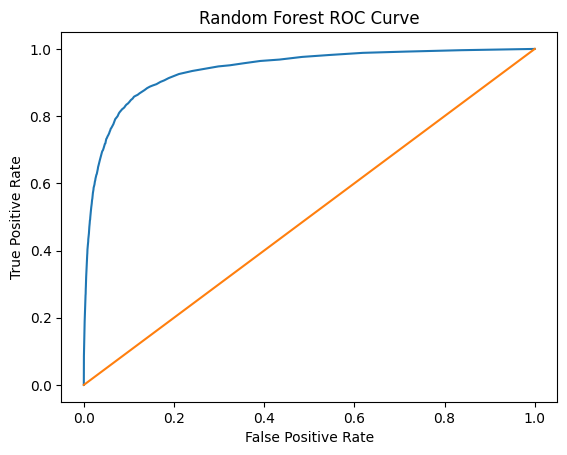

In [30]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

The curve is:

 - Strongly bowed toward the top-left

 - AUC ≈ 0.926

 - Far from diagonal

That confirms strong ranking ability independent of threshold.

Your interpretation earlier about separability is correct.

In [31]:
main_df = pd.read_sql('SELECT * FROM main_df', con=engine)

In [32]:
main_df.head()

,NCESSCH,SURVYEAR,LEAID,LEA_NAME,SCH_NAME,CHARTER_TEXT,MAGNET_TEXT,TOTFRL,FRELCH,REDLCH,PK,KG,G01,G02,G03,G04,G05,G06,G07,G08,G09,G10,G11,G12,G13,UG,TOTAL,FTE,STUTERATIO,AM,AS,BL,HP,HI,TR,WH,LATCOD,LONCOD,locale_category,TITLEI_GROUPED,high_strain
0,411129001772,2018,4111290,Sherwood SD 88J,Edy Ridge Elementary School,No,0,85,72,13,0,84,89,86,95,111,106,0,0,0,0,0,0,0,0,0,571,26.440001,21.6,2,21,3,0,77,45,423,45.3640,-122.8639,Suburb,Error,1
1,411145001769,2018,4111450,Silver Falls SD 4J,The Community Roots School,Yes,0,34,24,10,0,15,15,16,18,17,12,17,12,7,0,0,0,0,0,0,129,6.500000,19.8,1,1,0,0,8,9,109,45.0004,-122.7887,Town,Error,0
2,420081406994,2018,4200814,Vida Charter School,Vida Charter School,Yes,No,134,129,5,0,44,41,38,39,26,30,36,0,0,0,0,0,0,0,0,254,19.000000,13.4,0,1,8,0,153,9,83,39.8385,-77.2261,Suburb,Schoolwide,0
3,420081706985,2018,4200817,Franklin Towne Charter Elementary School,Franklin Towne Charter Elementary School,Yes,No,515,406,109,0,106,105,105,106,106,106,105,105,104,0,0,0,0,0,0,948,52.000000,18.2,1,9,48,2,84,25,779,40.0081,-75.0661,City,Schoolwide,0
4,420081807148,2018,4200818,Seven Generations Charter School,Seven Generations Charter School,Yes,No,96,96,0,0,71,66,52,54,38,36,0,0,0,0,0,0,0,0,0,317,32.150002,9.9,0,3,29,0,62,33,190,40.5366,-75.4851,Suburb,Targeted,0


In [33]:
econ_var_def_df = pd.read_sql('SELECT * FROM econ_var_def_2018_2022_rolling', con=engine)

In [34]:
econ_var_def_df.head(10)

,variable,label,concept,predicateType,group,limit,predicateOnly
0,DP03_0053EA,Annotation of Estimate!!INCOME AND BENEFITS (I...,Selected Economic Characteristics,string,DP03,0,True
1,DP03_0038PMA,Annotation of Percent Margin of Error!!INDUSTR...,Selected Economic Characteristics,string,DP03,0,True
2,DP03_0087PEA,Annotation of Percent!!INCOME AND BENEFITS (IN...,Selected Economic Characteristics,string,DP03,0,True
3,DP03_0048PM,Percent Margin of Error!!CLASS OF WORKER!!Civi...,Selected Economic Characteristics,float,DP03,0,True
4,DP03_0014PMA,Annotation of Percent Margin of Error!!EMPLOYM...,Selected Economic Characteristics,string,DP03,0,True
5,DP03_0075PEA,Annotation of Percent!!INCOME AND BENEFITS (IN...,Selected Economic Characteristics,string,DP03,0,True
6,DP03_0048PE,Percent!!CLASS OF WORKER!!Civilian employed po...,Selected Economic Characteristics,float,DP03,0,True
7,DP03_0035MA,Annotation of Margin of Error!!INDUSTRY!!Civil...,Selected Economic Characteristics,string,DP03,0,True
8,DP03_0066EA,Annotation of Estimate!!INCOME AND BENEFITS (I...,Selected Economic Characteristics,string,DP03,0,True
9,DP03_0097EA,Annotation of Estimate!!HEALTH INSURANCE COVER...,Selected Economic Characteristics,string,DP03,0,True


In [35]:
econ_var_def_df.shape

(1098, 7)

In [36]:
econ_var_def_df.columns

Index(['variable', 'label', 'concept', 'predicateType', 'group', 'limit',
       'predicateOnly'],
      dtype='str')

In [37]:
main_df["LEAID"].nunique()

7362

In [38]:
engine = db_connect()
main_econ_df = pd.read_sql('SELECT * FROM main_econ_view', con=engine)
main_econ_df.head(20)

Connection successful


,NCESSCH,SURVYEAR,LEAID,LEA_NAME,SCH_NAME,CHARTER_TEXT,MAGNET_TEXT,TOTFRL,FRELCH,REDLCH,PK,KG,G01,G02,G03,G04,G05,G06,G07,G08,G09,G10,G11,G12,G13,UG,TOTAL,FTE,STUTERATIO,AM,AS,BL,HP,HI,TR,WH,LATCOD,LONCOD,locale_category,TITLEI_GROUPED,high_strain,TH_10_15K,TH_15_25K,TH_WITH_CASH_ASSIST,TH_100_150K,TH_LT_10K,BPL_ALL_FAM,TH_50_75K,TH_75_100K,TH_25_35K,TH_150_200K,TH_35_50K,TH_WITH_SNAP,BPL_ALL,TH_200K_AND_ABOVE,econ_rolling_year_period
0,411129001772,2018,4111290,Sherwood SD 88J,Edy Ridge Elementary School,No,0,85,72,13,0,84,89,86,95,111,106,0,0,0,0,0,0,0,0,0,571,26.440001,21.6,2,21,3,0,77,45,423,45.3640,-122.8639,Suburb,Error,1,2.2,2.1,3.6,22.1,2.2,3.3,11.5,10.6,2.9,13.8,8.0,3.9,4.8,24.5,2018-2022
1,411145001769,2018,4111450,Silver Falls SD 4J,The Community Roots School,Yes,0,34,24,10,0,15,15,16,18,17,12,17,12,7,0,0,0,0,0,0,129,6.500000,19.8,1,1,0,0,8,9,109,45.0004,-122.7887,Town,Error,0,2.7,7.6,4.8,21.4,4.1,4.2,12.8,15.8,7.1,10.7,8.2,13.2,8.0,9.7,2018-2022
2,420681007335,2018,4206810,Cornell SD,Cornell HS,No,No,231,231,0,0,0,0,0,0,0,0,0,50,38,40,43,51,41,0,0,263,28.900000,9.1,0,1,40,0,15,35,172,40.5084,-80.1626,Suburb,Schoolwide,0,6.6,9.4,4.5,10.2,6.2,10.5,22.4,14.6,7.9,3.3,17.0,14.6,14.6,2.4,2018-2022
3,440063000471,2018,4400630,Middletown,Joseph Gaudet Academy,No,0,50,40,10,0,0,0,0,0,184,0,0,0,0,0,0,0,0,0,0,184,10.900000,16.9,0,7,13,0,21,12,131,41.5192,-71.2799,Suburb,Targeted,0,1.9,6.3,1.6,22.6,4.5,6.1,11.9,12.3,6.1,13.4,7.9,9.2,7.3,13.1,2018-2022
4,440090000474,2018,4400900,Providence,Nathan Bishop Middle,No,0,509,472,37,0,0,0,0,0,0,0,228,218,243,0,0,0,0,0,0,689,52.799999,13.0,9,17,116,0,376,40,131,41.8408,-71.3935,City,Schoolwide,0,7.5,8.8,10.8,13.7,7.3,16.9,16.6,12.2,7.7,6.6,10.9,28.1,21.3,8.8,2018-2022
5,460852001298,2018,4608520,Brookings School District 05-1,Camelot Intermediate - 06,No,0,136,101,35,0,0,0,0,0,239,325,0,0,0,0,0,0,0,0,0,564,35.250000,16.0,12,20,15,1,27,26,463,44.2894,-96.7827,Town,Targeted,0,6.0,6.4,0.7,20.1,3.7,5.3,22.3,11.0,8.4,7.0,11.6,5.5,14.2,3.5,2018-2022
6,461917001299,2018,4619170,Doland School District 56-2,Camrose Colony Elementary - 06,No,0,7,7,0,0,0,2,0,3,2,0,1,0,2,0,0,0,0,0,0,10,1.060000,9.4,0,0,0,0,0,0,10,44.9325,-98.2160,Rural,Schoolwide,0,7.1,5.9,0.9,11.5,7.1,11.0,19.8,19.5,4.7,5.0,6.5,4.1,17.2,13.0,2018-2022
7,462988001296,2018,4629880,Gregory School District 26-4,Gregory Junior High - 04,No,0,39,33,6,0,0,0,0,0,0,0,31,29,25,0,0,0,0,0,0,85,5.890000,14.4,16,3,1,1,1,4,59,43.2316,-99.4226,Rural,Schoolwide,0,5.6,15.8,0.3,11.2,3.4,5.7,12.9,10.0,10.4,11.2,15.4,5.1,8.9,4.0,2018-2022
8,466627001300,2018,4666270,Sioux Falls School District 49-5,RF Pettigrew Elementary - 17,No,0,197,152,45,121,157,149,139,128,145,130,0,0,0,0,0,0,0,0,0,969,50.349998,19.2,18,14,50,2,61,64,760,43.5056,-96.8245,City,Error,0,3.2,6.6,2.0,17.3,3.6,7.2,18.7,14.8,8.5,7.3,13.3,10.0,10.4,6.7,2018-2022
9,467452001301,2018,4674520,Viborg-Hurley School District 60-6,Cameron Colony Elementary - 04,No,0,0,0,0,0,2,1,0,4,2,4,0,1,5,0,0,0,0,0,0,19,2.000000,9.5,0,0,0,0,1,0,18,43.1883,-97.2626,Rural,Targeted,0,5.7,10.8,5.8,20.7,3.5,7.6,20.5,15.1,9.2,4.7,8.2,10.0,12.3,1.6,2018-2022


In [39]:
main_econ_df.columns

Index(['NCESSCH', 'SURVYEAR', 'LEAID', 'LEA_NAME', 'SCH_NAME', 'CHARTER_TEXT',
       'MAGNET_TEXT', 'TOTFRL', 'FRELCH', 'REDLCH', 'PK', 'KG', 'G01', 'G02',
       'G03', 'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11', 'G12',
       'G13', 'UG', 'TOTAL', 'FTE', 'STUTERATIO', 'AM', 'AS', 'BL', 'HP', 'HI',
       'TR', 'WH', 'LATCOD', 'LONCOD', 'locale_category', 'TITLEI_GROUPED',
       'high_strain', 'TH_10_15K', 'TH_15_25K', 'TH_WITH_CASH_ASSIST',
       'TH_100_150K', 'TH_LT_10K', 'BPL_ALL_FAM', 'TH_50_75K', 'TH_75_100K',
       'TH_25_35K', 'TH_150_200K', 'TH_35_50K', 'TH_WITH_SNAP', 'BPL_ALL',
       'TH_200K_AND_ABOVE', 'econ_rolling_year_period'],
      dtype='str')

In [40]:
main_econ_df.shape

(178675, 56)

## XGBoost

In [51]:
from sklearn.impute import SimpleImputer

preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [ ]:
from sklearn.metrics import make_scorer, precision_score

precision_scorer = make_scorer(precision_score, pos_label=1)

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=600,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=1.0,
        reg_alpha=1,
        reg_lambda=2,
        min_child_weight=5,
        random_state=42,
        eval_metric="logloss"
    ))
])

search = RandomizedSearchCV(
    xgb_model,
    param_distributions={
        "classifier__n_estimators": [200, 400, 600],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.7, 0.8, 1.0],
        "classifier__colsample_bytree": [0.7, 0.8, 1.0],
        "classifier__min_child_weight": [1, 3, 5]
    },
    n_iter=25,
    scoring=precision_scorer,
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [56]:

# Fit search
search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.7, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","make_scorer(p..., pos_label=1)"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:

In [57]:



# Best tuned model
best_xgb = search.best_estimator_

print("Best Params:", search.best_params_)

# Evaluate tuned model
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

thresholds = [0.30, 0.35, 0.40]

for t in thresholds:
    y_custom = (y_prob_xgb >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_custom))

Best Params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__min_child_weight': 3, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 1.0}
Tuned XGBoost ROC AUC: 0.8904116458026295

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     32390
           1       0.65      0.32      0.43      2650

    accuracy                           0.94     35040
   macro avg       0.80      0.66      0.70     35040
weighted avg       0.92      0.94      0.93     35040


Threshold: 0.35
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     32390
           1       0.71      0.27      0.39      2650

    accuracy                           0.94     35040
   macro avg       0.82      0.63      0.68     35040
weighted avg       0.92      0.94      0.92     35040


Threshold: 0.4
              precision    recall  f1-score

## stacked

In [59]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

In [60]:
rf_stack = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ))
])

xgb_stack = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=600,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=1.0,
        min_child_weight=5,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [61]:
stack_model = StackingClassifier(
    estimators=[
        ("rf", rf_stack),
        ("xgb", xgb_stack)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    n_jobs=1,
    passthrough=False
)

In [62]:
stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...max_iter=2000)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by nam

In [63]:
y_prob_stack = stack_model.predict_proba(X_test)[:,1]
y_pred_stack = (y_prob_stack >= 0.25).astype(int)

print("Stacked ROC AUC:", roc_auc_score(y_test, y_prob_stack))
print("\nStacked Classification Report:\n")
print(classification_report(y_test, y_pred_stack))

Stacked ROC AUC: 0.9437626567715403

Stacked Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     32390
           1       0.65      0.63      0.64      2650

    accuracy                           0.95     35040
   macro avg       0.81      0.80      0.81     35040
weighted avg       0.95      0.95      0.95     35040



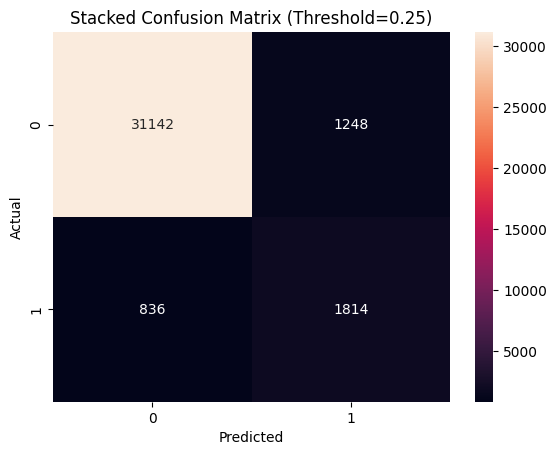

In [64]:
y_pred_stack = (y_prob_stack >= 0.25).astype(int)

cm = confusion_matrix(y_test, rf_custom)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Stacked Confusion Matrix (Threshold=0.25)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [65]:
rf = stack_model.named_estimators_['rf']
xgb = stack_model.named_estimators_['xgb']